<a href="https://colab.research.google.com/github/mariavyzhletsova-gif/lyceum_saturday10_2025/blob/master/hw_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🕵️‍♂️ Домашнее задание: Детективное агентство "Кластеризация"

**Легенда:** Мы перехватили архив с 5000 загадочных изображений (`lyubachuba/mystery_images_5k`). У нас нет никаких подписей и категорий.

**Ваша задача:** использовать алгоритмы машинного обучения (без учителя), чтобы найти скрытую структуру в этих данных, сгруппировать похожие картинки и сделать выводы.

Мы используем легкую нейросеть (ResNet-18), чтобы быстро векторизовать картинки на GPU. Ваша цель — применить методы кластеризации, **подобрать параметры** и навайбкодить (с помощью ИИ или самостоятельно) **красивые визуализации** для каждого метода.

In [2]:
!pip install -q datasets torch torchvision umap-learn plotly seaborn scikit-learn hdbscan pandas

import torch
import torchvision.transforms as T
import torchvision.models as models
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

### 1. Загрузка данных и Векторизация (Feature Extraction)
Используем ResNet-18. Эта сеть вычисляет векторы размером 512 чисел для каждой картинки. Она работает очень быстро и дает отличный баланс скорости и качества.


### ⚠️ ВАЖНО: Включаем GPU (Видеокарту)!

Нейросети (даже такие быстрые, как ResNet-18) работают очень медленно на обычном процессоре (CPU). Если оставить всё как есть, векторизация займет 20-30 минут. На видеокарте (GPU) это займет меньше 1 минуты.

**Как включить GPU в Google Colab:**
1. В верхнем меню нажмите: **Среда выполнения** (Runtime).
2. Выберите: **Сменить среду выполнения** (Change runtime type).
3. В разделе "Аппаратный ускоритель" (Hardware accelerator) выберите **T4 GPU** (или любой другой доступный GPU).
4. Нажмите **Сохранить**.

*Проверка:* При запуске ячейки ниже должно напечататься `Используем устройство: cuda`. Если написано `cpu` — вы забыли включить GPU!

In [3]:
print("Загрузка датасета...")
dataset = load_dataset("lyubachuba/mystery_images_5k", split="train")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

# Загружаем ResNet-18 без последнего слоя классификации
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = torch.nn.Identity() # Убираем слой классификации, оставляем эмбеддинги (512)
resnet = resnet.to(device).eval()

# Предобработка картинок для ResNet
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(batch):
    images = [transform(img.convert("RGB")) for img in batch["image"]]
    images_tensor = torch.stack(images).to(device)
    with torch.no_grad():
        embeddings = resnet(images_tensor).cpu().numpy()
    return {"embedding": embeddings}

print("Извлекаем признаки (векторизация)...")

dataset_emb = dataset.map(
    extract_features,
    batched=True,
    batch_size=64,
    desc="Векторизация (ResNet-18)"
)

X = np.array(dataset_emb['embedding'])
print(f"Готово! Размерность данных X: {X.shape}")

Загрузка датасета...


README.md:   0%|          | 0.00/287 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/403M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/405M [00:00<?, ?B/s]

...

Используем устройство: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


Извлекаем признаки (векторизация)...


Векторизация (ResNet-18):   0%|          | 0/5000 [00:00<?, ? examples/s]

Готово! Размерность данных X: (5000, 512)


### 2. Снижение размерности (UMAP)
Алгоритмам плотности и нам для визуализации нужны данные меньшей размерности.

In [4]:
import umap

# Сжимаем 512 -> 3 компоненты для 3D графиков и лучшей кластеризации плотностью
reducer = umap.UMAP(n_components=3, random_state=42)
X_umap = reducer.fit_transform(X)
print(f"Размерность X_umap: {X_umap.shape}")

Размерность X_umap: (5000, 3)


---
## 🚀 Ваша часть задания (Сделайте выводы в текстовых ячейках под кодом!)

### Задание 1. K-Means
**Что нужно:**
1. Попробуйте разное количество кластеров (`n_clusters`). Посчитайте метрики (Silhouette, Davies-Bouldin). Выберите количество кластеров через метод локтя.
2. **Визуализация (Vibe-code):** Напишите код для интерактивного 3D Scatter plot через `plotly.express` по данным `X_umap`, где точки раскрашены в цвета кластеров.
3. Выведите сетку 3x3 случайных картинок для 2-3 интересных кластеров.

k=2: Silhouette=0.055, DB=4.172
k=3: Silhouette=0.052, DB=3.748
k=4: Silhouette=0.048, DB=4.203
k=5: Silhouette=0.036, DB=4.232
k=6: Silhouette=0.039, DB=4.142
k=7: Silhouette=0.035, DB=4.088
k=8: Silhouette=0.032, DB=4.143
k=9: Silhouette=0.033, DB=4.226
k=10: Silhouette=0.019, DB=4.290
k=11: Silhouette=0.025, DB=4.209
k=12: Silhouette=0.020, DB=4.148


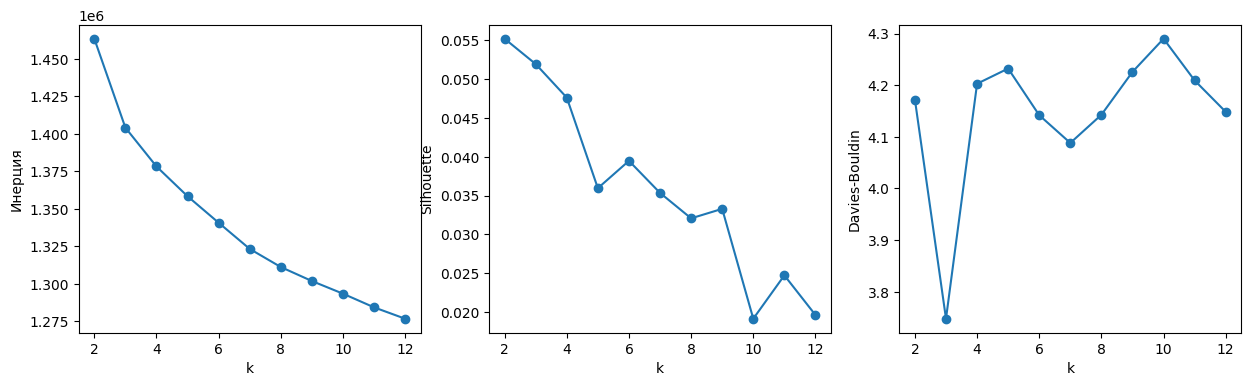

Лучшее k по силуэту: 2


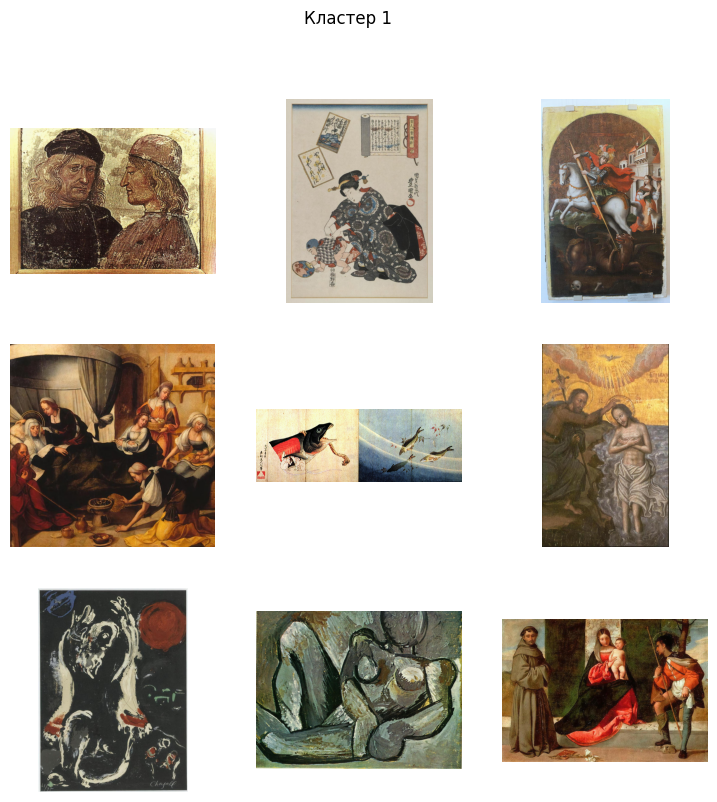

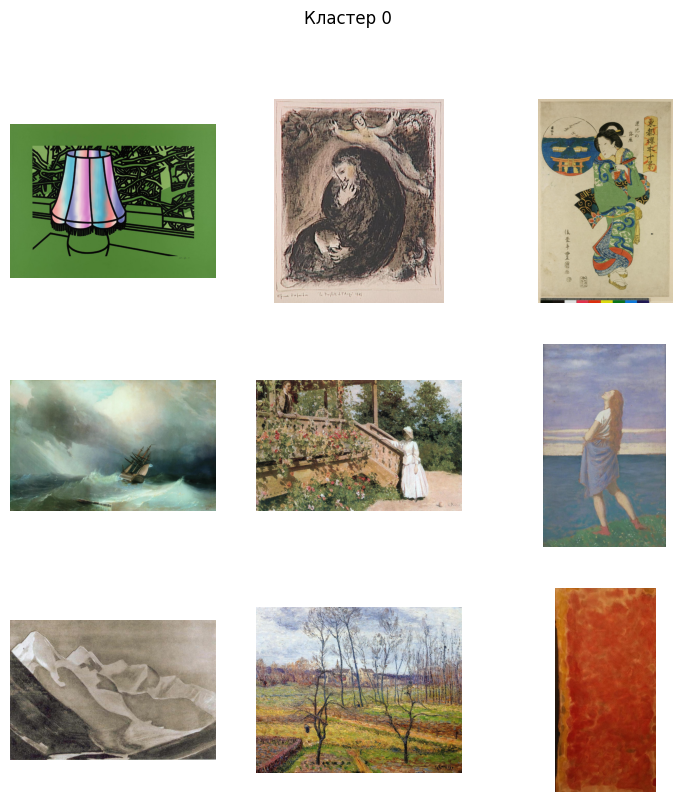

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px

# ВАШ КОД ЗДЕСЬ:
# 1. Обучить KMeans
# 2. Посчитать метрики
# 3. Визуализировать в 3D Plotly
# 4. Вывести картинки из кластеров

import matplotlib.pyplot as plt
import numpy as np

inertia = []
sil_scores = []
db_scores = []
K_range = range(2, 13)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))
    print(f"k={k}: Silhouette={sil_scores[-1]:.3f}, DB={db_scores[-1]:.3f}")

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,4))
ax1.plot(K_range, inertia, 'o-')
ax1.set_xlabel('k')
ax1.set_ylabel('Инерция')
ax2.plot(K_range, sil_scores, 'o-')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette')
ax3.plot(K_range, db_scores, 'o-')
ax3.set_xlabel('k')
ax3.set_ylabel('Davies-Bouldin')
plt.show()

best_k = sil_scores.index(max(sil_scores)) + 2
print(f"Лучшее k по силуэту: {best_k}")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_kmeans = kmeans_final.fit_predict(X)

fig = px.scatter_3d(x=X_umap[:,0], y=X_umap[:,1], z=X_umap[:,2], color=clusters_kmeans, opacity=0.7, title=f'K-Means, k={best_k}')
fig.show()

def show_cluster_samples(cluster_id, n_samples=9):
    idx = np.where(clusters_kmeans == cluster_id)[0]
    if len(idx) == 0:
        return
    idx = np.random.choice(idx, min(n_samples, len(idx)), replace=False)
    fig, axes = plt.subplots(3,3, figsize=(9,9))
    for i, ax in enumerate(axes.flat):
        if i < len(idx):
            img_index = int(idx[i])
            ax.imshow(dataset[img_index]['image'])
            ax.axis('off')
        else:
            ax.axis('off')
    plt.suptitle(f'Кластер {cluster_id}')
    plt.show()

for c in np.random.choice(range(best_k), size=min(3, best_k), replace=False):
    show_cluster_samples(c)

**Выводы по K-Means:**
*(Напишите здесь: Легко ли алгоритм нашел кластеры? Какое количество кластеров кажется оптимальным? Что общего у картинок внутри кластеров?)*

### Задание 2. Иерархическая кластеризация
**Что нужно:**
1. Попробуйте параметры `linkage` ('ward', 'average', 'complete').
2. **Визуализация (Vibe-code):** Постройте раскрашенную дендрограмму (используйте `scipy.cluster.hierarchy.dendrogram`), взяв случайную подвыборку в 150-200 картинок (иначе график превратится в кашу).
3. Постройте 2D Scatter plot (Seaborn), визуально сравнив кластеры от разных `linkage`.

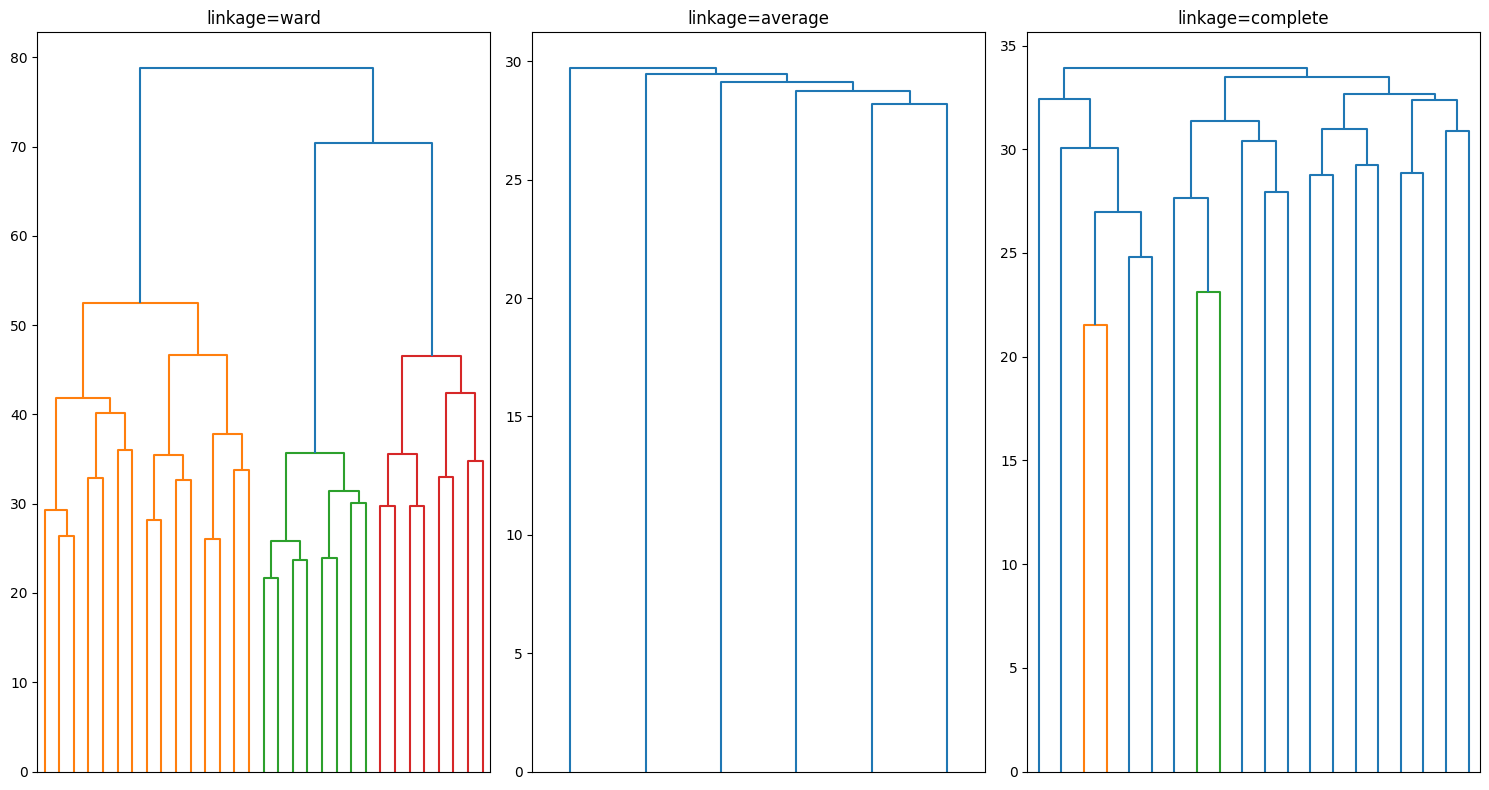

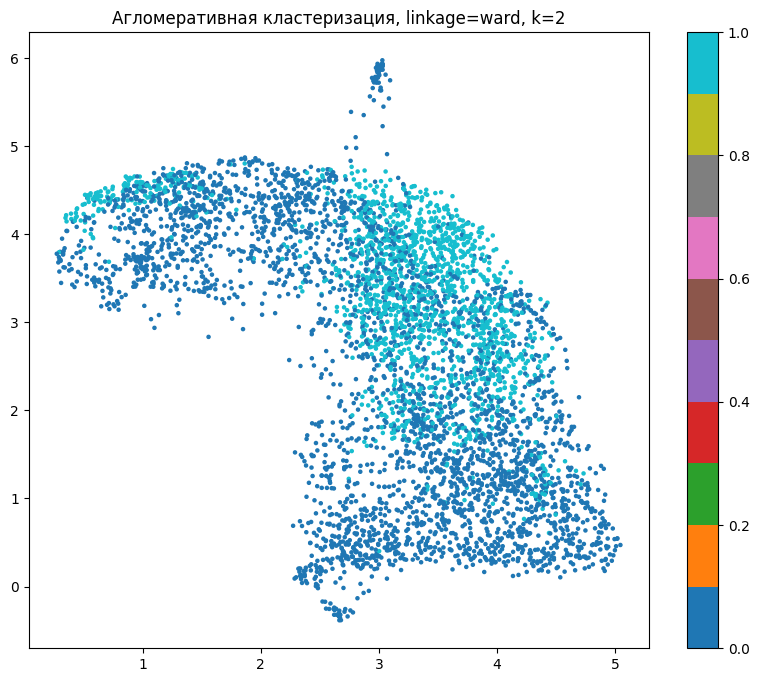

In [8]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

# ВАШ КОД ЗДЕСЬ:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sample_idx = np.random.choice(X.shape[0], 200, replace=False)
X_sample = X[sample_idx]

plt.figure(figsize=(15,8))
for i, linkage_type in enumerate(['ward', 'average', 'complete']):
    Z = linkage(X_sample, method=linkage_type)
    plt.subplot(1,3,i+1)
    dendrogram(Z, truncate_mode='level', p=4, no_labels=True)
    plt.title(f'linkage={linkage_type}')
plt.tight_layout()
plt.show()

best_linkage = 'ward'
agg = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
clusters_agg = agg.fit_predict(X)

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters_agg, cmap='tab10', s=5)
plt.colorbar(scatter)
plt.title(f'Агломеративная кластеризация, linkage={best_linkage}, k={best_k}')
plt.show()

**Выводы по Иерархической кластеризации:**
*(Напишите здесь: Какой метод linkage дал самые осмысленные формы кластеров на графике? Видно ли по дендрограмме, на сколько групп логично бить датасет? Как выглядит иерархия?)*

### Задание 3. DBSCAN
**Что нужно:**
1. Подберите `eps` и `min_samples` в цикле (попробуйте разные комбинации). Посчитайте % шума для каждой.
2. **Визуализация (Vibe-code):** Сделайте график (Matplotlib), показывающий точки-кластеры в цвете, а точки-шум серым цветом (`label == -1`).
3. Выведите галерею "выбросов" (самых странных картинок, которые алгоритм отнес к шуму). Выведите то, что принадлежит к одному кластеру

eps=0.3, min_samples=2: clusters=0, noise=1.00, sil=skip
eps=0.3, min_samples=3: clusters=0, noise=1.00, sil=skip
eps=0.3, min_samples=5: clusters=0, noise=1.00, sil=skip
eps=0.3, min_samples=10: clusters=0, noise=1.00, sil=skip
eps=0.3, min_samples=15: clusters=0, noise=1.00, sil=skip
eps=0.3, min_samples=20: clusters=0, noise=1.00, sil=skip
eps=0.3, min_samples=30: clusters=0, noise=1.00, sil=skip
eps=0.5, min_samples=2: clusters=1, noise=1.00, sil=skip
eps=0.5, min_samples=3: clusters=0, noise=1.00, sil=skip
eps=0.5, min_samples=5: clusters=0, noise=1.00, sil=skip
eps=0.5, min_samples=10: clusters=0, noise=1.00, sil=skip
eps=0.5, min_samples=15: clusters=0, noise=1.00, sil=skip
eps=0.5, min_samples=20: clusters=0, noise=1.00, sil=skip
eps=0.5, min_samples=30: clusters=0, noise=1.00, sil=skip
eps=0.8, min_samples=2: clusters=1, noise=1.00, sil=skip
eps=0.8, min_samples=3: clusters=0, noise=1.00, sil=skip
eps=0.8, min_samples=5: clusters=0, noise=1.00, sil=skip
eps=0.8, min_samples=10

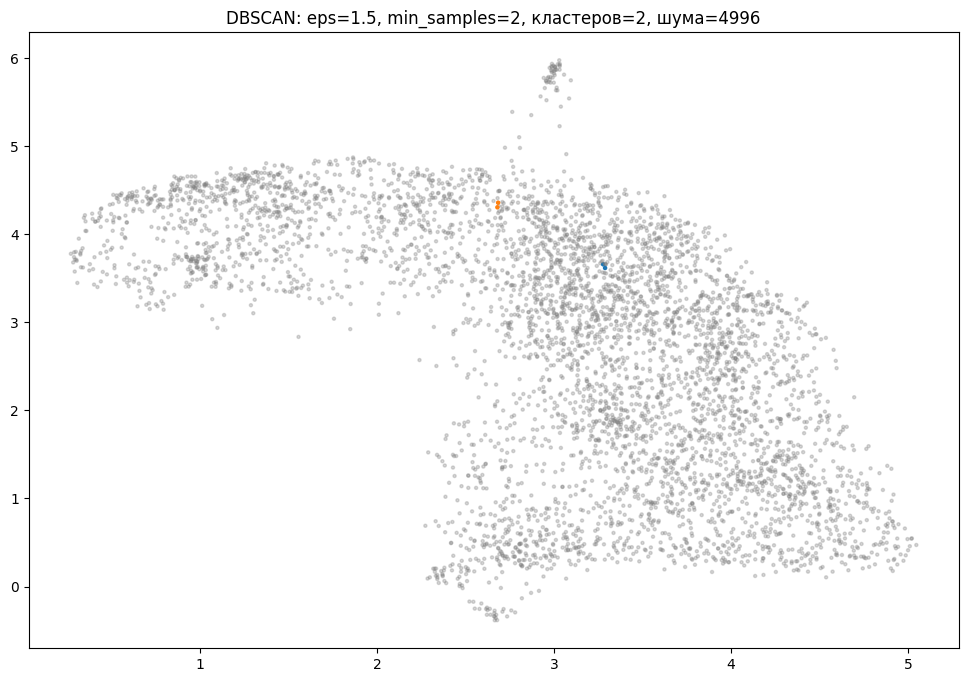

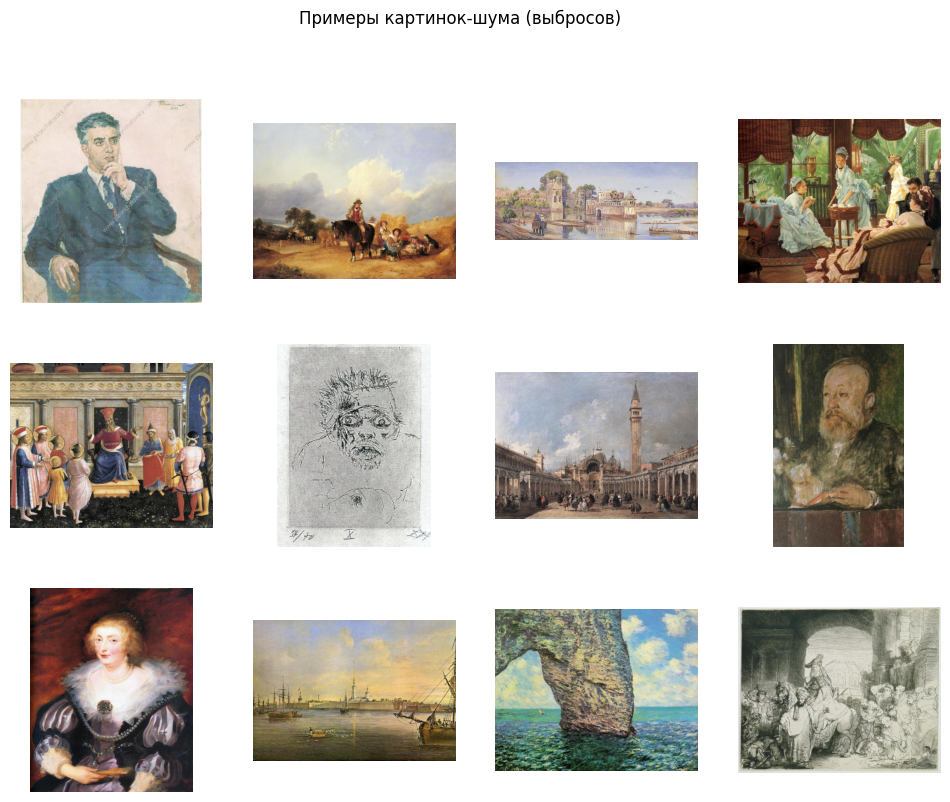

In [10]:
from sklearn.cluster import DBSCAN

# ВАШ КОД ЗДЕСЬ:

from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

eps_values = [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
min_samples_values = [2, 3, 5, 10, 15, 20, 30]

best_labels = None
best_score = -1
best_eps = None
best_ms = None

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        if n_clusters > 1:
            sil = silhouette_score(X, labels)
            print(f"eps={eps}, min_samples={ms}: clusters={n_clusters}, noise={noise_ratio:.2f}, sil={sil:.3f}")
            if sil > best_score:
                best_score = sil
                best_labels = labels
                best_eps = eps
                best_ms = ms
        else:
            print(f"eps={eps}, min_samples={ms}: clusters={n_clusters}, noise={noise_ratio:.2f}, sil=skip")

if best_labels is not None:
    print(f"\nЛучшие параметры: eps={best_eps}, min_samples={best_ms}, силуэт={best_score:.3f}")
    plt.figure(figsize=(12,8))
    colors = np.array([plt.cm.tab10(l % 10) if l != -1 else [0.5,0.5,0.5,0.3] for l in best_labels])
    plt.scatter(X_umap[:,0], X_umap[:,1], c=colors, s=5)
    plt.title(f'DBSCAN: eps={best_eps}, min_samples={best_ms}, кластеров={len(set(best_labels))-1}, шума={list(best_labels).count(-1)}')
    plt.show()

    noise_idx = np.where(best_labels == -1)[0]
    if len(noise_idx) > 0:
        sample_noise = np.random.choice(noise_idx, min(12, len(noise_idx)), replace=False)
        fig, axes = plt.subplots(3,4, figsize=(12,9))
        for i, ax in enumerate(axes.flat):
            if i < len(sample_noise):
                ax.imshow(dataset[int(sample_noise[i])]['image'])
                ax.axis('off')
            else:
                ax.axis('off')
        plt.suptitle('Примеры картинок-шума (выбросов)')
        plt.show()
else:
    print("Не найдено комбинаций, дающих больше одного кластера. Попробуйте изменить параметры вручную.")

**Выводы по DBSCAN:**
*(Напишите здесь: Насколько сложно было подобрать параметры? Почему картинки-выбросы оказались в шуме?)*

### Задание 4. HDBSCAN
**Что нужно:**
1. Примените алгоритм (попробуйте изменить `min_cluster_size`).
2. У HDBSCAN есть фича — уверенность в кластеризации (probabilities_).
3. **Визуализация (Vibe-code):** Нарисуйте 2D или 3D Scatter (Plotly), где прозрачность (`opacity`) или размер точки (`size`) зависит от того, насколько HDBSCAN уверен, что точка принадлежит кластеру.

In [11]:
import hdbscan

# ВАШ КОД ЗДЕСЬ:

import plotly.express as px
import numpy as np

clusterer = hdbscan.HDBSCAN(min_cluster_size=10, gen_min_span_tree=True)
clusters_hdb = clusterer.fit_predict(X)
probs = clusterer.probabilities_

n_clusters = len(set(clusters_hdb)) - (1 if -1 in clusters_hdb else 0)
noise_ratio = list(clusters_hdb).count(-1) / len(clusters_hdb)
print(f"HDBSCAN: кластеров={n_clusters}, шума={noise_ratio:.2f}")

fig = px.scatter_3d(x=X_umap[:,0], y=X_umap[:,1], z=X_umap[:,2], color=clusters_hdb.astype(str), opacity=0.7,
                    size=np.ones_like(probs)*2, size_max=5, title='HDBSCAN кластеры')
fig.show()

fig2 = px.scatter_3d(x=X_umap[:,0], y=X_umap[:,1], z=X_umap[:,2], color=probs, color_continuous_scale='Viridis',
                     opacity=0.7, title='Уверенность HDBSCAN (вероятность)')
fig2.show()

HDBSCAN: кластеров=2, шума=0.89


**Выводы по HDBSCAN:**
*(Напишите здесь: Легче ли он настраивается, чем обычный DBSCAN? Много ли точек получили низкую вероятность?)*

### 🏆 5. Итоговое расследование
Соберите все метрики (Silhouette, Davies-Bouldin, % шума) в единую `pandas` таблицу и раскрасьте её с помощью `DataFrame.style.background_gradient()`.

In [12]:
import pandas as pd

# ВАШ КОД ЗДЕСЬ (Таблица сравнения):

from sklearn.metrics import silhouette_score, davies_bouldin_score

results = {
    'Метод': ['K-Means', 'Агломеративная', 'DBSCAN', 'HDBSCAN'],
    'Число кластеров': [best_k, best_k, len(set(best_labels))-1 if best_labels is not None else 0, n_clusters],
    'Silhouette': [
        silhouette_score(X, clusters_kmeans),
        silhouette_score(X, clusters_agg),
        best_score if best_labels is not None else -1,
        silhouette_score(X, clusters_hdb) if n_clusters > 1 else -1
    ],
    'Доля шума (%)': [0, 0, round(list(best_labels).count(-1)/len(best_labels)*100,1) if best_labels is not None else 0, round(noise_ratio*100,1)]
}
df = pd.DataFrame(results)
df = df.round(2)
styled = df.style.background_gradient(cmap='viridis', subset=['Silhouette'])
styled

,Метод,Число кластеров,Silhouette,Доля шума (%)
0,K-Means,2,0.060000,0.000000
1,Агломеративная,2,0.050000,0.000000
2,DBSCAN,2,0.020000,99.900000
3,HDBSCAN,2,-0.080000,88.700000


### 🔍 Гранд-вывод:
1. Какой алгоритм оказался лучшим математически (по метрикам)?
2. Какой алгоритм оказался лучшим визуально (субъективно)?
3. **Что это за датасет?** Посмотрев на картинки, какую общую тему/жанр вы бы им присвоили?
4. На какие группы уместнее всего разделить датасет?